# Chapter 10 Your data under a different lens: Window functions
we will disucss
- Window functions and the kind of data transformation they enable
- Summarizing, ranking, and analyzing data using the different classes of window functions
- Building static, growing, and unbounded windows to your functions
- Apply UDF to windows as custom window functions

In [1]:
import sys
from pyspark.sql import SparkSession
from pyspark.sql.utils import AnalysisException
import pyspark.sql.functions as F
import pyspark.sql.types as T
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.window import Window

import warnings
warnings.filterwarnings('ignore')

# change the account name to your email account
account='sli'

# define a root path to access the data in the DataAnalysisWithPythonAndPySpark
data_path='/net/clusterhn/home/'+account+'/isa460/data/'

# check if the Spark session is active. If it is activate, close it

try:
    if spark:
        spark.stop()
except:
    pass    

spark = (SparkSession.builder.appName("Window Functions")
        .config("spark.port.maxRetries", "100")
        .config("spark.sql.mapKeyDedupPolicy", "LAST_WIN")  # This configuration allow the duplicate keys in the map data type.
         .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
        .config("spark.driver.memory", "8g")
        .config("spark.driver.executor","8g")
        .getOrCreate())

# confiture the log level (defaulty is WARN)
spark.sparkContext.setLogLevel('ERROR')

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/04 15:21:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/04 15:21:24 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/10/04 15:21:24 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


# <span style="color:red">**Note: You do not need to run the following code. It was provided as a reference.**</span>

## Extract Weather data

For this exercise, we will download the data directly from NOAA's National Centers for Environmental Information (NCEI)

Boston Logan Weather Data: Column Definitions

Source: NOAA NCEI Global Surface Summary of the Day (GSOD), station 72509014739 (Boston Logan International Airport), 2010–2025.

| Column | Definition | Unit |
|---|---|---|
| `date` | Observation date | YYYY-MM-DD |
| `avg_temp_f` | Mean temperature for the day | °F |
| `max_temp_f` | Highest temperature reported during the day | °F |
| `min_temp_f` | Lowest temperature reported during the day | °F |
| `precip_in` | Total precipitation (rain plus melted snow) | inches |
| `snow_depth_in` | Snow depth on the ground, from the last report of the day | inches |
| `wind_knots` | Mean wind speed for the day | knots (1 knot ≈ 1.15 mph) |
| `gust_knots` | Maximum wind gust reported | knots |
| `visibility_mi` | Mean visibility for the day | miles |
| `weather_flags` | 6-digit indicator (FRSHTT) for Fog, Rain/drizzle, Snow/ice pellets, Hail, Thunder, Tornado; 1 = occurred, 0 = did not | code |
| `year` | Year extracted from `date` | integer |
| `month` | Month extracted from `date` | 1–12 |

**Notes**
- Missing-value codes (9999.9, 999.9, 99.99) were replaced with `NaN`.
- Max/min temperatures may include part of the previous day.
- A precipitation value of 0.00 can mean either no rain or no report.
- `weather_flags` is read as a string so leading zeros are kept (e.g., `010010` = rain and thunder).

In [9]:
# import data from Boston Logan weather station

import pandas as pd
import numpy as np

# Boston Logan (USAF 725090 + WBAN 14739)
url = 'https://www.ncei.noaa.gov/data/global-summary-of-the-day/access/{}/72509014739.csv'

# Load 2010–2025 data
frames = [pd.read_csv(url.format(y)) for y in range(2010, 2026)]
weather = pd.concat(frames, ignore_index=True)
weather['DATE'] = pd.to_datetime(weather['DATE'])

# Replace GSOD missing-value codes with NaN
missing_codes = {
    'TEMP': 9999.9, 'DEWP': 9999.9, 'SLP': 9999.9, 'STP': 9999.9,
    'MAX': 9999.9,  'MIN': 9999.9,
    'VISIB': 999.9, 'WDSP': 999.9, 'MXSPD': 999.9, 'GUST': 999.9, 'SNDP': 999.9,
    'PRCP': 99.99
}
for col, code in missing_codes.items():
    weather[col] = weather[col].replace(code, np.nan)

# Keep useful columns
weather = weather[['DATE', 'TEMP', 'MAX', 'MIN', 'PRCP', 'SNDP',
                   'WDSP', 'GUST', 'VISIB', 'FRSHTT']].rename(columns={
    'DATE': 'date', 'TEMP': 'avg_temp_f', 'MAX': 'max_temp_f', 'MIN': 'min_temp_f',
    'PRCP': 'precip_in', 'SNDP': 'snow_depth_in', 'WDSP': 'wind_knots',
    'GUST': 'gust_knots', 'VISIB': 'visibility_mi', 'FRSHTT': 'weather_flags'
})

# create year and month column
weather['year'] = weather['date'].dt.year
weather['month'] = weather['date'].dt.month

# To turn the flags into separate yes/no columns:
flags = weather['weather_flags'].astype(str).str.zfill(6)
for i, name in enumerate(['fog', 'rain', 'snow', 'hail', 'thunder', 'tornado']):
    weather[name] = flags.str[i].astype(int)

weather.head()

,date,avg_temp_f,max_temp_f,min_temp_f,precip_in,snow_depth_in,wind_knots,gust_knots,visibility_mi,weather_flags,year,month,fog,rain,snow,hail,thunder,tornado
0,2010-01-01,29.6,35.1,26.1,0.12,NaN,5.9,NaN,6.6,11000,2010,1,0,1,1,0,0,0
1,2010-01-02,28.6,35.1,25.0,0.01,NaN,11.4,28.9,2.7,111000,2010,1,1,1,1,0,0,0
2,2010-01-03,22.3,30.2,17.1,0.06,NaN,19.1,35.9,3.0,101000,2010,1,1,0,1,0,0,0
3,2010-01-04,30.5,35.1,17.1,0.01,NaN,15.0,28.9,8.7,1000,2010,1,0,0,1,0,0,0
4,2010-01-05,29.2,33.1,26.6,0.00,NaN,8.8,15.0,10.0,0,2010,1,0,0,0,0,0,0


In [12]:
weather.shape

(5718, 18)

In [14]:
weather.columns

Index(['date', 'avg_temp_f', 'max_temp_f', 'min_temp_f', 'precip_in',
       'snow_depth_in', 'wind_knots', 'gust_knots', 'visibility_mi',
       'weather_flags', 'year', 'month', 'fog', 'rain', 'snow', 'hail',
       'thunder', 'tornado'],
      dtype='object')

In [16]:
# store weather data into data folder

weather.to_csv('data/boston_logan_weather_2010_2025.csv', index=False)

In [17]:
# read csv file
df=spark.read.csv(data_path+'boston_logan_weather_2010_2025.csv', header=True, inferSchema=True)

df.printSchema()

root
 |-- date: string (nullable = true)
 |-- avg_temp_f: double (nullable = true)
 |-- max_temp_f: double (nullable = true)
 |-- min_temp_f: double (nullable = true)
 |-- precip_in: double (nullable = true)
 |-- snow_depth_in: string (nullable = true)
 |-- wind_knots: double (nullable = true)
 |-- gust_knots: double (nullable = true)
 |-- visibility_mi: double (nullable = true)
 |-- weather_flags: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- fog: integer (nullable = true)
 |-- rain: integer (nullable = true)
 |-- snow: integer (nullable = true)
 |-- hail: integer (nullable = true)
 |-- thunder: integer (nullable = true)
 |-- tornado: integer (nullable = true)



In [18]:
df.count()

5718

In [19]:
df.show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+
|2010-01-01|      29.6|      35.1|      26.1|     0.12|         NULL|       5.9|      NULL|          6.6|        11000|2010|    1|  0|   1|   1|   0|      0|      0|
|2010-01-02|      28.6|      35.1|      25.0|     0.01|         NULL|      11.4|      28.9|          2.7|       111000|2010|    1|  1|   1|   1|   0|      0|      0|
|2010-01-03|      22.3|      30.2|      17.1|     0.06|         NULL|      19.1|      35.9|          3.0|       101000|2010|    1|  1|   0|   1|   0|      0|      0|
|201

In [26]:
# covert date to date format, create a day, year-month column

df1=(df.withColumn('date', F.to_date('date'))
      . withColumn('day', F.dayofmonth('date'))
      .withColumn('year_month', F.date_format('date', 'yyyy-MM')))

df1.printSchema()

root
 |-- date: date (nullable = true)
 |-- avg_temp_f: double (nullable = true)
 |-- max_temp_f: double (nullable = true)
 |-- min_temp_f: double (nullable = true)
 |-- precip_in: double (nullable = true)
 |-- snow_depth_in: string (nullable = true)
 |-- wind_knots: double (nullable = true)
 |-- gust_knots: double (nullable = true)
 |-- visibility_mi: double (nullable = true)
 |-- weather_flags: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- fog: integer (nullable = true)
 |-- rain: integer (nullable = true)
 |-- snow: integer (nullable = true)
 |-- hail: integer (nullable = true)
 |-- thunder: integer (nullable = true)
 |-- tornado: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- year_month: string (nullable = true)



In [28]:
# store weather data as parquet for fast processing

df1.write.parquet(data_path+'boston_logan_weather_2010_2025.parquet')

# load the weather data in parquet format

In [29]:
df=spark.read.parquet(data_path+'boston_logan_weather_2010_2025.parquet')

# Display average temperature by year

In [87]:
df1=df.groupBy('year').agg(F.avg('avg_temp_f').alias('avg_temp')).orderBy('year')

df1.show()

+----+------------------+
|year|          avg_temp|
+----+------------------+
|2010| 53.56986301369865|
|2011| 53.22767123287676|
|2012| 53.95409836065571|
|2013|51.822739726027415|
|2014|  51.0098630136986|
|2015| 51.52986301369862|
|2016| 53.08251366120225|
|2017| 52.39616438356164|
|2018|52.800821917808214|
|2019|53.201643835616466|
|2020| 53.29590163934425|
|2021| 54.42657534246579|
|2022|53.477260273972625|
|2023| 53.93452054794522|
|2024| 53.46338797814212|
|2025| 53.20920502092048|
+----+------------------+



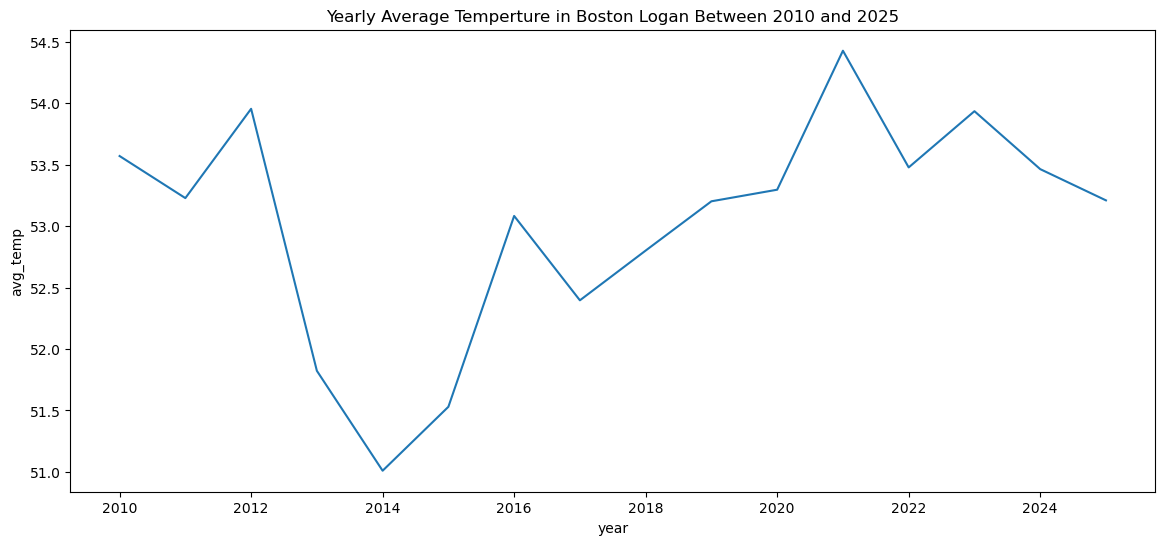

In [90]:
# visualize the result

result=df1.toPandas()

plt.figure(figsize=(14, 6))

sns.lineplot(data=result, x='year', y='avg_temp')

plt.title('Yearly Average Temperture in Boston Logan Between 2010 and 2025');

# Display daily temperature 

In [31]:
result=df.toPandas()

result.head()

,date,avg_temp_f,max_temp_f,min_temp_f,precip_in,snow_depth_in,wind_knots,gust_knots,visibility_mi,weather_flags,year,month,fog,rain,snow,hail,thunder,tornado,day,year_month
0,2010-01-01,29.6,35.1,26.1,0.12,None,5.9,NaN,6.6,11000,2010,1,0,1,1,0,0,0,1,2010-01
1,2010-01-02,28.6,35.1,25.0,0.01,None,11.4,28.9,2.7,111000,2010,1,1,1,1,0,0,0,2,2010-01
2,2010-01-03,22.3,30.2,17.1,0.06,None,19.1,35.9,3.0,101000,2010,1,1,0,1,0,0,0,3,2010-01
3,2010-01-04,30.5,35.1,17.1,0.01,None,15.0,28.9,8.7,1000,2010,1,0,0,1,0,0,0,4,2010-01
4,2010-01-05,29.2,33.1,26.6,0.00,None,8.8,15.0,10.0,0,2010,1,0,0,0,0,0,0,5,2010-01


Text(0.5, 1.0, 'Daily Temperture in Boston Logan Between 2010 and 2025')

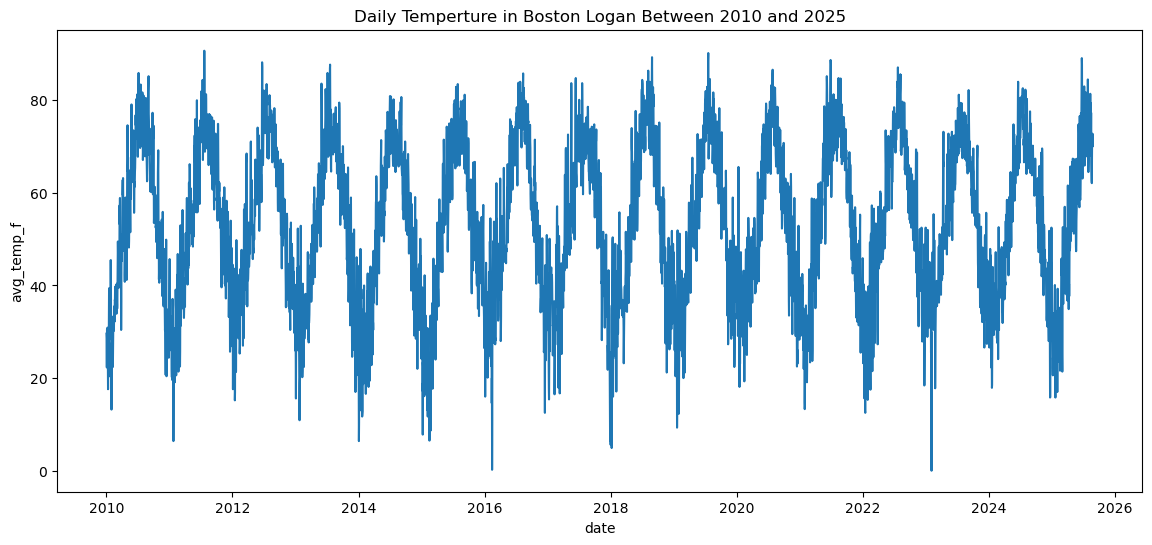

In [33]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=result, x='date', y='avg_temp_f')

plt.title('Daily Temperture in Boston Logan Between 2010 and 2025')

## Identify the coldest day of each year

In [41]:
from pyspark.sql.window import Window

windowSpec=Window.partitionBy('year')

result=df.withColumn('coldestDay', F.min('avg_temp_f').over(windowSpec))

result2=result.where('avg_temp_f=coldestDay')

result2.show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|coldestDay|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----------+
|2010-01-30|      13.2|      21.9|       6.1|      0.0|         NULL|      12.7|      29.9|         10.0|            0|2010|    1|  0|   0|   0|   0|      0|      0| 30|   2010-01|      13.2|
|2011-01-24|       6.4|      24.1|      -2.0|      0.0|         NULL|      12.1|      26.0|         10.0|            0|2011|    1|  0|   0|   0|   0|      0|      0| 24|   2011-01|       6.4|
|2012-01-15|      15.2|      34.0|      

## Identify the hottest day of each year

In [42]:
windowSpec=Window.partitionBy('year')

result=df.withColumn('hottestDay', F.max('avg_temp_f').over(windowSpec))

result2=result.where('avg_temp_f=hottestDay')

result2.show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|hottestDay|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----------+
|2010-07-06|      85.9|     100.0|      75.0|      0.0|         NULL|       7.2|      20.0|         10.0|            0|2010|    7|  0|   0|   0|   0|      0|      0|  6|   2010-07|      85.9|
|2011-07-22|      90.7|     102.9|      73.0|      0.0|         NULL|      12.1|      26.0|          7.9|            0|2011|    7|  0|   0|   0|   0|      0|      0| 22|   2011-07|      90.7|
|2012-06-21|      88.2|      97.0|      

# Ranking functions

This section covers ranking functions: 
- nonconsecutive ranks with rank()
- consecutive ranks with dense_rank()
- percentile ranks with percent_rank()
- tiles with ntile(), 
- finally a bare row number with row_number()

Ranking functions are used for getting the top (or bottom) record for each window partition, or, more generally, for getting an order according to some column’s value.

## Identify the top 3 hottest days per year

In [43]:
windowSpec=Window.partitionBy('year').orderBy(F.desc('avg_temp_f'))

result=df.withColumn('rank', F.rank().over(windowSpec)).filter(F.col('rank')<=3)

result.show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|rank|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----+
|2010-07-06|      85.9|     100.0|      75.0|      0.0|         NULL|       7.2|      20.0|         10.0|            0|2010|    7|  0|   0|   0|   0|      0|      0|  6|   2010-07|   1|
|2010-09-02|      85.2|      95.0|      73.0|      0.0|         NULL|      10.2|      22.0|          9.4|            0|2010|    9|  0|   0|   0|   0|      0|      0|  2|   2010-09|   2|
|2010-09-01|      84.4|      96.1|      77.0|      0.0|         NULL| 

## Identify the top 5% of the hottest day per year

In [45]:
windowSpec=Window.partitionBy('year').orderBy('avg_temp_f')

result=df.withColumn('percent_rank', F.percent_rank().over(windowSpec)).where('percent_rank>=0.95')
result.show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+------------------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|      percent_rank|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+------------------+
|2010-07-19|      79.8|      91.0|      68.0|      0.0|         NULL|       9.4|      19.0|         10.0|        10000|2010|    7|  0|   1|   0|   0|      0|      0| 19|   2010-07|0.9505494505494505|
|2010-08-05|      80.0|      91.9|      73.9|      0.0|         NULL|       9.3|      31.1|          7.1|       110010|2010|    8|  1|   1|   0|   0|      1|      0|  5|   2010-08|0.9532967032967034|


### Split the temp per year into 10 equal buckets (decile)

In [46]:
windowSpec=Window.partitionBy('year').orderBy('avg_temp_f')

result=df.withColumn('decile', F.ntile(10).over(windowSpec)).groupBy('year', 'decile').count().orderBy('year', 'decile')
result.show()

+----+------+-----+
|year|decile|count|
+----+------+-----+
|2010|     1|   37|
|2010|     2|   37|
|2010|     3|   37|
|2010|     4|   37|
|2010|     5|   37|
|2010|     6|   36|
|2010|     7|   36|
|2010|     8|   36|
|2010|     9|   36|
|2010|    10|   36|
|2011|     1|   37|
|2011|     2|   37|
|2011|     3|   37|
|2011|     4|   37|
|2011|     5|   37|
|2011|     6|   36|
|2011|     7|   36|
|2011|     8|   36|
|2011|     9|   36|
|2011|    10|   36|
+----+------+-----+
only showing top 20 rows



In [47]:
# check the temp in decile (10% of the coldest temperature in each year)

windowSpec=Window.partitionBy('year').orderBy('avg_temp_f')

df.withColumn('decile', F.ntile(10).over(windowSpec)).where('decile=1').show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|decile|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+------+
|2010-01-30|      13.2|      21.9|       6.1|      0.0|         NULL|      12.7|      29.9|         10.0|            0|2010|    1|  0|   0|   0|   0|      0|      0| 30|   2010-01|     1|
|2010-01-10|      17.6|      28.0|      10.9|      0.0|         NULL|      11.1|      25.1|         10.0|            0|2010|    1|  0|   0|   0|   0|      0|      0| 10|   2010-01|     1|
|2010-01-29|      18.6|      37.0|      12.9|     0.02|     

## Add a row number to your data frame, ignore tie

In [48]:
windowSpec=Window.partitionBy('year').orderBy('avg_temp_f')

df.withColumn('row_number', F.row_number().over(windowSpec)).show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|row_number|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+----------+
|2010-01-30|      13.2|      21.9|       6.1|      0.0|         NULL|      12.7|      29.9|         10.0|            0|2010|    1|  0|   0|   0|   0|      0|      0| 30|   2010-01|         1|
|2010-01-10|      17.6|      28.0|      10.9|      0.0|         NULL|      11.1|      25.1|         10.0|            0|2010|    1|  0|   0|   0|   0|      0|      0| 10|   2010-01|         2|
|2010-01-29|      18.6|      37.0|      

## Access the records before or after using lag() and lead()

## Display average daily temp change by month

In [51]:
windowSpec=Window.partitionBy('year_month').orderBy('day')

df2=df.select('year_month', 'day', 'avg_temp_f', F.lag('avg_temp_f').over(windowSpec).alias('pre_temp'))

df2.show()

df3=df2.withColumn('daily_temp_change', F.abs(F.col('avg_temp_f')-F.col('pre_temp')))

df3.show()

df4=df3.groupBy('year_month').agg(F.round(F.avg('daily_temp_change'), 2).alias('avgTempChange'))

df4.show()

+----------+---+----------+--------+
|year_month|day|avg_temp_f|pre_temp|
+----------+---+----------+--------+
|   2010-01|  1|      29.6|    NULL|
|   2010-01|  2|      28.6|    29.6|
|   2010-01|  3|      22.3|    28.6|
|   2010-01|  4|      30.5|    22.3|
|   2010-01|  5|      29.2|    30.5|
|   2010-01|  6|      28.7|    29.2|
|   2010-01|  7|      30.9|    28.7|
|   2010-01|  8|      27.4|    30.9|
|   2010-01|  9|      22.9|    27.4|
|   2010-01| 10|      17.6|    22.9|
|   2010-01| 11|      25.2|    17.6|
|   2010-01| 12|      29.3|    25.2|
|   2010-01| 13|      20.3|    29.3|
|   2010-01| 14|      27.5|    20.3|
|   2010-01| 15|      35.6|    27.5|
|   2010-01| 16|      39.4|    35.6|
|   2010-01| 17|      37.3|    39.4|
|   2010-01| 18|      33.7|    37.3|
|   2010-01| 19|      32.2|    33.7|
|   2010-01| 20|      34.0|    32.2|
+----------+---+----------+--------+
only showing top 20 rows

+----------+---+----------+--------+------------------+
|year_month|day|avg_temp_f|pre

#### Visualize the result

In [54]:
result=df4.toPandas()

result.head()

,year_month,avgTempChange
0,2010-01,4.76
1,2010-02,1.97
2,2010-03,4.36
3,2010-04,4.61
4,2010-05,4.72


<Axes: xlabel='year_month', ylabel='avgTempChange'>

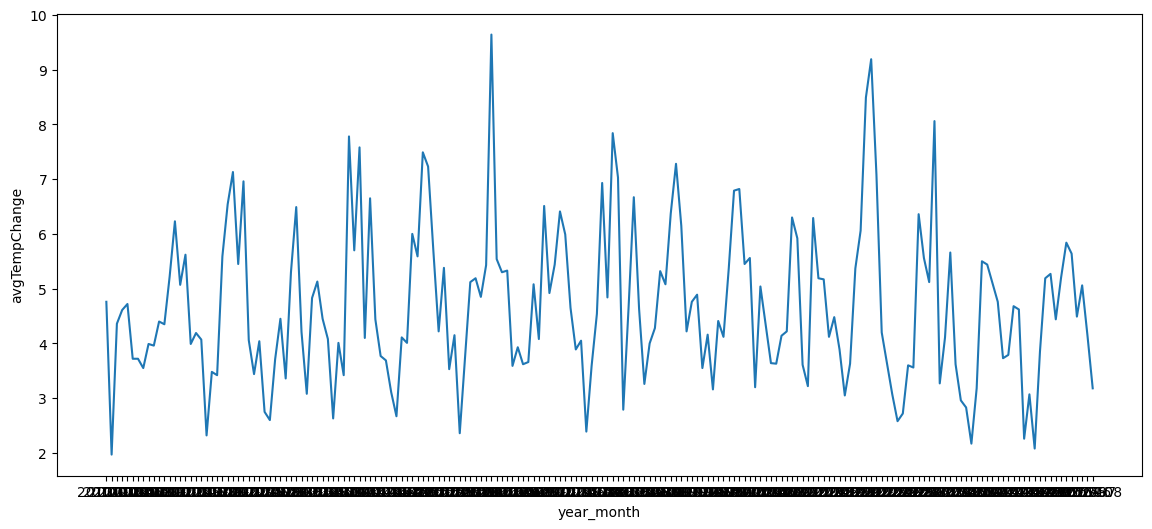

In [55]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=result, x='year_month', y='avgTempChange')

#### fix year_month display

##### Option 1: convert year_month to date format

In [59]:
result.dtypes

year_month        object
avgTempChange    float64
dtype: object

In [60]:
# convert year_month to Date

result['year_month'] = pd.to_datetime(result['year_month'], format='%Y-%m')

result.dtypes

year_month       datetime64[ns]
avgTempChange           float64
dtype: object

<Axes: xlabel='year_month', ylabel='avgTempChange'>

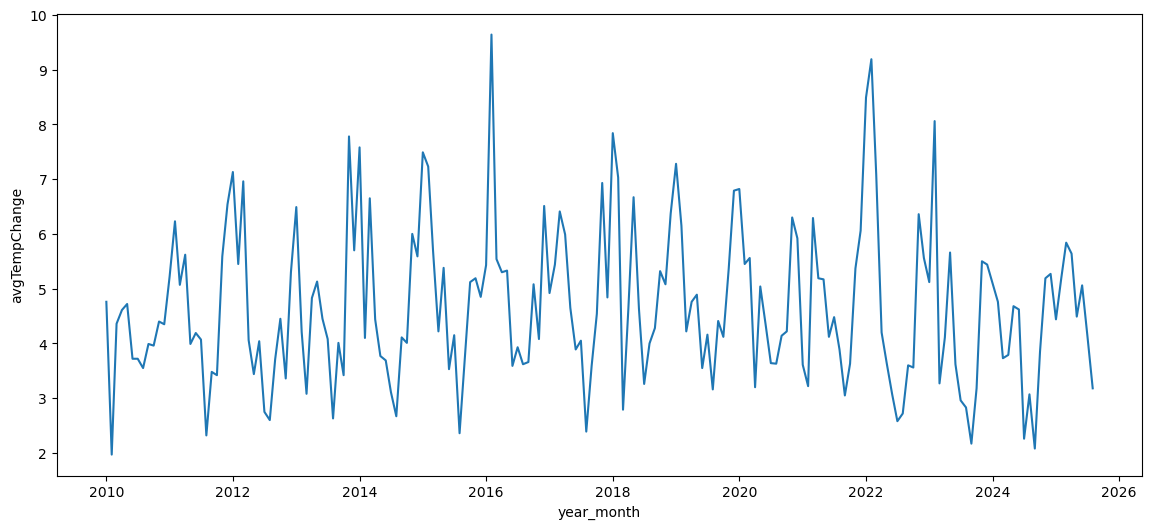

In [61]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=result, x='year_month', y='avgTempChange')

##### keep year_month as string, show every sixth label

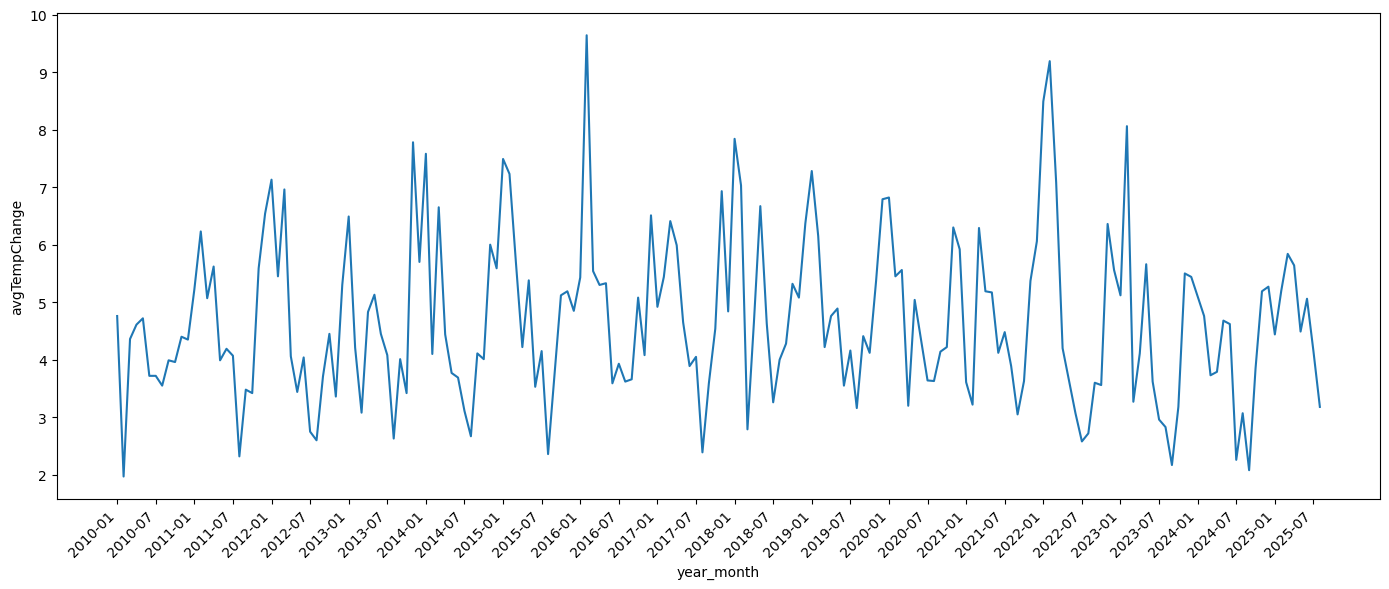

In [66]:
result=df4.toPandas()

plt.figure(figsize=(14, 6))

ax = sns.lineplot(data=result, x='year_month', y='avgTempChange')

# Show every sixth label
labels = result['year_month'].tolist()
ax.set_xticks(range(0, len(labels), 6))
ax.set_xticklabels(labels[::6], rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### display avg, max and min temp change by month

In [67]:
df3.show()

+----------+---+----------+--------+------------------+
|year_month|day|avg_temp_f|pre_temp| daily_temp_change|
+----------+---+----------+--------+------------------+
|   2010-01|  1|      29.6|    NULL|              NULL|
|   2010-01|  2|      28.6|    29.6|               1.0|
|   2010-01|  3|      22.3|    28.6| 6.300000000000001|
|   2010-01|  4|      30.5|    22.3|               8.2|
|   2010-01|  5|      29.2|    30.5|1.3000000000000007|
|   2010-01|  6|      28.7|    29.2|               0.5|
|   2010-01|  7|      30.9|    28.7|2.1999999999999993|
|   2010-01|  8|      27.4|    30.9|               3.5|
|   2010-01|  9|      22.9|    27.4|               4.5|
|   2010-01| 10|      17.6|    22.9| 5.299999999999997|
|   2010-01| 11|      25.2|    17.6| 7.599999999999998|
|   2010-01| 12|      29.3|    25.2| 4.100000000000001|
|   2010-01| 13|      20.3|    29.3|               9.0|
|   2010-01| 14|      27.5|    20.3| 7.199999999999999|
|   2010-01| 15|      35.6|    27.5| 8.100000000

In [70]:
df4=df3.groupBy('year_month').agg(F.round(F.avg('daily_temp_change'),2).alias('avgTempChange')
                                , F.round(F.min('daily_temp_change'),2).alias('minTempChange')
                               , F.round(F.max('daily_temp_change'),2).alias('maxTempChange')
                               )
df4.show()

+----------+-------------+-------------+-------------+
|year_month|avgTempChange|minTempChange|maxTempChange|
+----------+-------------+-------------+-------------+
|   2010-01|         4.76|          0.1|         14.3|
|   2010-02|         1.97|          0.1|          4.9|
|   2010-03|         4.36|          0.2|         12.5|
|   2010-04|         4.61|          0.2|         10.9|
|   2010-05|         4.72|          0.2|         16.8|
|   2010-06|         3.72|          0.0|          9.2|
|   2010-07|         3.72|          0.1|          9.5|
|   2010-08|         3.55|          0.1|          9.0|
|   2010-09|         3.99|          0.2|         11.8|
|   2010-10|         3.96|          0.0|         14.3|
|   2010-11|          4.4|          0.1|         12.8|
|   2010-12|         4.35|          0.0|         17.8|
|   2011-01|         5.22|          0.0|         12.2|
|   2011-02|         6.23|          0.9|         16.6|
|   2011-03|         5.07|          0.0|         15.9|
|   2011-0

##### Visualize the result

In [75]:
result=df4.toPandas()

result.head()

,year_month,avgTempChange,minTempChange,maxTempChange
0,2010-01,4.76,0.1,14.3
1,2010-02,1.97,0.1,4.9
2,2010-03,4.36,0.2,12.5
3,2010-04,4.61,0.2,10.9
4,2010-05,4.72,0.2,16.8


In [76]:
result2 = pd.melt(result, id_vars=['year_month'], value_vars=['avgTempChange', 'maxTempChange', 'minTempChange'], 
                    var_name='temp_stat', value_name='temperature')

result2.head()

,year_month,temp_stat,temperature
0,2010-01,avgTempChange,4.76
1,2010-02,avgTempChange,1.97
2,2010-03,avgTempChange,4.36
3,2010-04,avgTempChange,4.61
4,2010-05,avgTempChange,4.72


In [77]:
# convert year_month to date format
result2['year_month'] = pd.to_datetime(result2['year_month'], format='%Y-%m')

Text(0, 0.5, 'Taemperature Change')

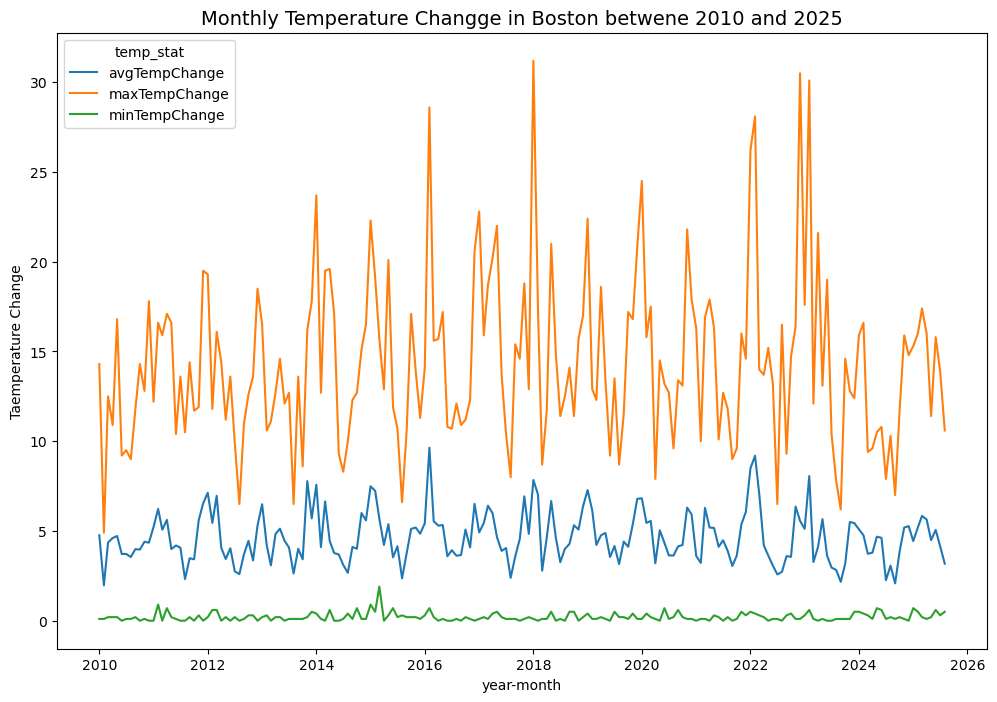

In [78]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=result2, x='year_month', y='temperature', hue='temp_stat')

plt.title('Monthly Temperature Changge in Boston betwene 2010 and 2025', size=14)
plt.xlabel('year-month')
plt.ylabel('Taemperature Change')

## Spark also provides the rowsBetween() and rangeBetween() methods to create window frame boundaries.

### Display three days moving average temp for each month

In [79]:
df.columns

['date',
 'avg_temp_f',
 'max_temp_f',
 'min_temp_f',
 'precip_in',
 'snow_depth_in',
 'wind_knots',
 'gust_knots',
 'visibility_mi',
 'weather_flags',
 'year',
 'month',
 'fog',
 'rain',
 'snow',
 'hail',
 'thunder',
 'tornado',
 'day',
 'year_month']

In [80]:
windowSpec=Window.partitionBy('year_month').orderBy('day').rowsBetween(-2,0)

df1=df.withColumn('3_day_moving_avg', F.avg('avg_temp_f').over(windowSpec))

df1.show()

+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+------------------+
|      date|avg_temp_f|max_temp_f|min_temp_f|precip_in|snow_depth_in|wind_knots|gust_knots|visibility_mi|weather_flags|year|month|fog|rain|snow|hail|thunder|tornado|day|year_month|  3_day_moving_avg|
+----------+----------+----------+----------+---------+-------------+----------+----------+-------------+-------------+----+-----+---+----+----+----+-------+-------+---+----------+------------------+
|2010-01-01|      29.6|      35.1|      26.1|     0.12|         NULL|       5.9|      NULL|          6.6|        11000|2010|    1|  0|   1|   1|   0|      0|      0|  1|   2010-01|              29.6|
|2010-01-02|      28.6|      35.1|      25.0|     0.01|         NULL|      11.4|      28.9|          2.7|       111000|2010|    1|  1|   1|   1|   0|      0|      0|  2|   2010-01|              29.1|


# Summary

- Window functions are functions that are applied over a portion of a data frame called a window frame. They can perform aggregation, ranking, or analytical operations. A window function will return the data frame with the same number of records, unlike its siblings the groupby-aggregate operation and the group map UDF.
- A window frame is defined through a window spec. A window spec mandates how the data frame is split (partitionBy()), how it’s ordered (orderBy()), and how it’s portioned (rowsBetween()/rangeBetween()).
- By default, an unordered window frame will be unbounded, meaning that the window frame will be equal to the window partition for every record. An ordered window frame will grow to the left, meaning that each record will have a window frame ranging from the first record in the window partition to the current record.
- A window can be bounded by row, meaning that the records included in the window frame are tied to the row boundaries passed as parameters (with the range boundaries added to the row number of the current row), or by range, meaning that the records included in the window frame depend on the value of the current row (with the range boundaries added to the value).

# Practice: Window functions

Use the weather data frame `df` loaded above. Every question can be answered with a
window function. Work in the empty cell under each question, and check each result
with `show()` before moving on.


## Question 1: Unusually warm days

For every day, compute the average temperature of the month (`year_month`) that the
day belongs to, and how many degrees the day's average temperature was above that
monthly average. Every row of the data should be kept.

Show the 10 days that were furthest above their month's average, with the date, the
day's average temperature, the month's average (rounded to 1 decimal), and the
difference (rounded to 1 decimal).


In [91]:
# Solution
windowSpec = Window.partitionBy('year_month')

q1 = (df.withColumn('month_avg', F.avg('avg_temp_f').over(windowSpec))
        .withColumn('above_avg', F.round(F.col('avg_temp_f') - F.col('month_avg'), 1))
        .select('date', 'avg_temp_f', F.round('month_avg', 1).alias('month_avg'), 'above_avg')
        .orderBy(F.desc('above_avg')))

q1.show(10)

+----------+----------+---------+---------+
|      date|avg_temp_f|month_avg|above_avg|
+----------+----------+---------+---------+
|2017-05-18|      83.7|     55.9|     27.8|
|2020-01-12|      65.6|     38.1|     27.5|
|2013-05-31|      83.6|     58.2|     25.4|
|2017-05-19|      80.2|     55.9|     24.3|
|2022-02-23|      57.3|     33.3|     24.0|
|2013-11-01|      65.5|     42.7|     22.8|
|2023-04-14|      73.2|     50.4|     22.8|
|2012-03-23|      68.5|     45.9|     22.6|
|2020-12-01|      58.9|     36.3|     22.6|
|2012-03-22|      67.9|     45.9|     22.0|
+----------+----------+---------+---------+
only showing top 10 rows



## Question 2: Record-warm months

Compute the average temperature for every year and month. Then, for each calendar
month (January through December), find the year in which that month was the warmest.

Show one row per month, ordered by month, with the year and that month's average
temperature (rounded to 1 decimal).


In [92]:
# Solution
monthly = df.groupBy('year', 'month').agg(F.round(F.avg('avg_temp_f'), 1).alias('month_avg_temp'))

windowSpec = Window.partitionBy('month').orderBy(F.desc('month_avg_temp'))

q2 = (monthly.withColumn('rank', F.rank().over(windowSpec))
             .where('rank = 1')
             .orderBy('month'))

q2.show()

+----+-----+--------------+----+
|year|month|month_avg_temp|rank|
+----+-----+--------------+----+
|2020|    1|          38.1|   1|
|2018|    2|          38.1|   1|
|2012|    3|          45.9|   1|
|2010|    4|          52.8|   1|
|2010|    5|          62.2|   1|
|2021|    6|          74.2|   1|
|2019|    7|          78.3|   1|
|2018|    8|          76.9|   1|
|2021|    9|          69.8|   1|
|2017|   10|          61.3|   1|
|2011|   11|          50.1|   1|
|2015|   12|          44.8|   1|
+----+-----+--------------+----+



## Question 3: Sharpest cold snap

For each year, find the day with the largest one-day drop in average temperature,
compared with the previous day in the data.

Show one row per year with the year, the date, the previous day's temperature, the
day's temperature, and the size of the drop (rounded to 1 decimal).


In [93]:
# Solution
windowSpec = Window.partitionBy('year').orderBy('date')

drops = (df.withColumn('prev_temp', F.lag('avg_temp_f').over(windowSpec))
           .withColumn('temp_drop', F.round(F.col('prev_temp') - F.col('avg_temp_f'), 1)))

rankSpec = Window.partitionBy('year').orderBy(F.desc('temp_drop'))

q3 = (drops.withColumn('rank', F.row_number().over(rankSpec))
           .where('rank = 1')
           .select('year', 'date', 'prev_temp', 'avg_temp_f', 'temp_drop')
           .orderBy('year'))

q3.show()

+----+----------+---------+----------+---------+
|year|      date|prev_temp|avg_temp_f|temp_drop|
+----+----------+---------+----------+---------+
|2010|2010-12-14|     49.9|      32.1|     17.8|
|2011|2011-12-29|     48.1|      28.6|     19.5|
|2012|2012-12-06|     53.6|      35.1|     18.5|
|2013|2013-02-01|     52.9|      31.5|     21.4|
|2014|2014-01-07|     44.3|      20.6|     23.7|
|2015|2015-01-06|     39.6|      17.3|     22.3|
|2016|2016-02-14|     20.0|       0.2|     19.8|
|2017|2017-01-14|     48.6|      25.8|     22.8|
|2018|2018-01-14|     50.4|      19.2|     31.2|
|2019|2019-01-31|     33.3|      12.3|     21.0|
|2020|2020-01-13|     65.6|      41.1|     24.5|
|2021|2021-04-22|     59.4|      41.5|     17.9|
|2022|2022-12-24|     48.9|      18.4|     30.5|
|2023|2023-02-04|     25.0|      -0.0|     25.0|
|2024|2024-02-29|     52.6|      36.0|     16.6|
|2025|2025-03-02|     42.5|      25.1|     17.4|
+----+----------+---------+----------+---------+



## Question 4: Wettest week

For each day, compute the total precipitation over that day and the six records
before it within the same year. (A few days are missing from the data, so count six
previous records rather than six calendar days.)

Show the five dates with the largest seven-day totals, with that day's precipitation
and the seven-day total (rounded to 2 decimals).


In [94]:
# Solution
windowSpec = Window.partitionBy('year').orderBy('date').rowsBetween(-6, 0)

q4 = (df.withColumn('precip_7day', F.round(F.sum('precip_in').over(windowSpec), 2))
        .select('date', 'precip_in', 'precip_7day')
        .orderBy(F.desc('precip_7day')))

q4.show(5)

+----------+---------+-----------+
|      date|precip_in|precip_7day|
+----------+---------+-----------+
|2013-06-14|     1.61|       8.02|
|2010-03-18|      0.0|       7.06|
|2010-03-16|     1.25|       7.06|
|2010-03-17|      0.0|       7.06|
|2021-09-04|      0.0|       7.02|
+----------+---------+-----------+
only showing top 5 rows



## Question 5: Reaching 20 inches of precipitation

For each year, compute a running (year-to-date) total of precipitation that starts on
the first day of the year and adds each day in date order.

Then find the first date in each year on which the running total reached 20 inches or
more. Show one row per year, ordered by year.


In [95]:
# Solution
windowSpec = (Window.partitionBy('year').orderBy('date')
                    .rowsBetween(Window.unboundedPreceding, Window.currentRow))

running = df.withColumn('ytd_precip', F.round(F.sum('precip_in').over(windowSpec), 2))

q5 = (running.where('ytd_precip >= 20')
             .groupBy('year')
             .agg(F.min('date').alias('date_reached_20in'))
             .orderBy('year'))

q5.show()

+----+-----------------+
|year|date_reached_20in|
+----+-----------------+
|2010|       2010-03-31|
|2011|       2011-06-23|
|2012|       2012-07-29|
|2013|       2013-06-14|
|2014|       2014-06-11|
|2015|       2015-07-10|
|2016|       2016-08-22|
|2017|       2017-06-06|
|2018|       2018-06-05|
|2019|       2019-05-13|
|2020|       2020-07-24|
|2021|       2021-07-02|
|2022|       2022-09-20|
|2023|       2023-06-27|
|2024|       2024-04-05|
|2025|       2025-05-31|
+----+-----------------+

